In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Simulated evaluation results

np.random.seed(42)

classes = ["Low", "Medium", "High"]

# Actual demand classes for 1,000 apparel products
y_true = np.random.choice(
    classes,
    size=1000,
    p=[0.30, 0.45, 0.25]
)

# Simulated predictions with different model performance
def simulate_predictions(y_true, accuracy):
    predictions = y_true.copy()
    
    n_errors = int(len(y_true) * (1 - accuracy))
    error_indices = np.random.choice(
        len(y_true),
        size=n_errors,
        replace=False
    )
    
    for idx in error_indices:
        possible_classes = [c for c in classes if c != y_true[idx]]
        predictions[idx] = np.random.choice(possible_classes)
    
    return predictions


y_pred_logistic = simulate_predictions(y_true, 0.82)
y_pred_rf = simulate_predictions(y_true, 0.89)
y_pred_gb = simulate_predictions(y_true, 0.92)

print("Simulated evaluation data created successfully.")
print(f"Number of products evaluated: {len(y_true)}")

Simulated evaluation data created successfully.
Number of products evaluated: 1000


In [4]:
# Calculate evaluation metrics

models = {
    "Logistic Regression": y_pred_logistic,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

print("Model evaluation completed.")
results_df

Model evaluation completed.


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.820,0.823304,0.820,0.820715
1,Random Forest,0.891,0.891348,0.891,0.891098
2,Gradient Boosting,0.921,0.921489,0.921,0.921130


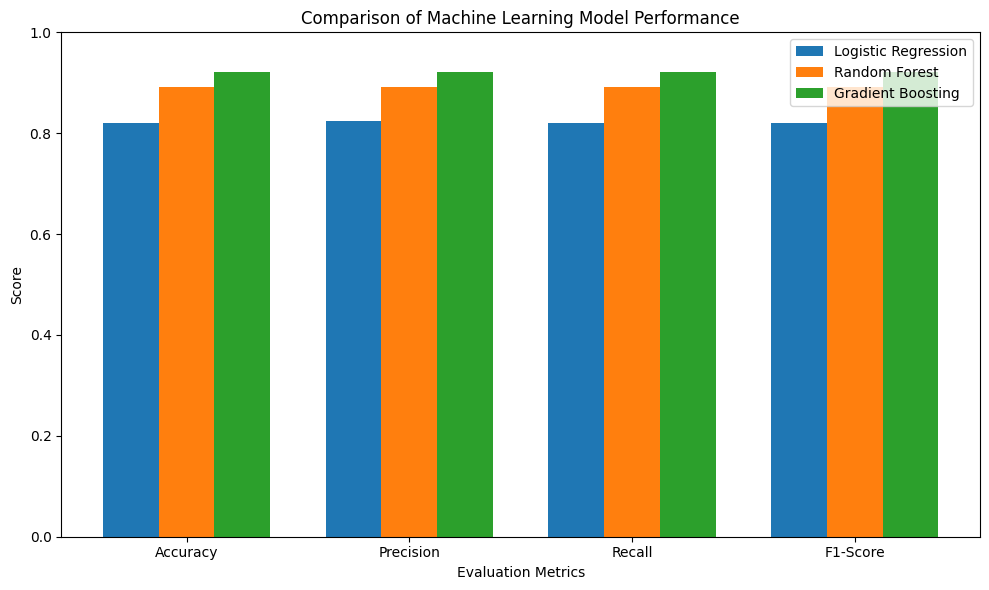

In [5]:
# Model performance comparison

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

for i, model_name in enumerate(results_df["Model"]):
    values = results_df.loc[
        results_df["Model"] == model_name,
        metrics
    ].values[0]

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model_name
    )

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Comparison of Machine Learning Model Performance")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.show()

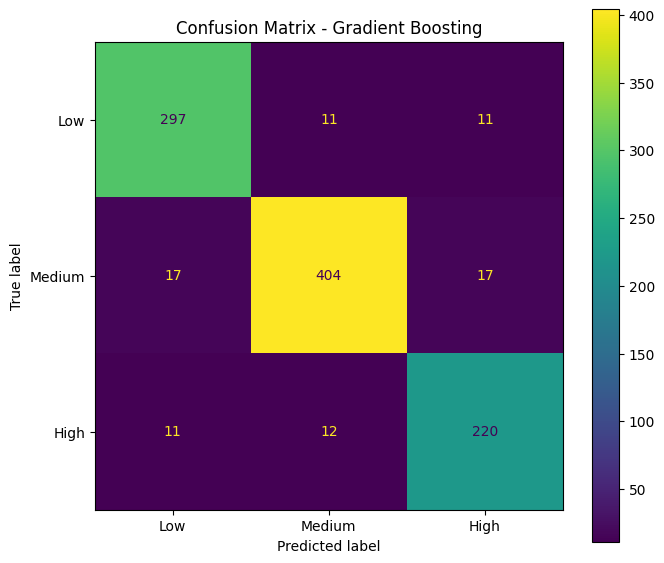

In [6]:
# Confusion matrix for the best-performing model

cm = confusion_matrix(
    y_true,
    y_pred_gb,
    labels=classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)

plt.title("Confusion Matrix - Gradient Boosting")
plt.tight_layout()

plt.show()

In [7]:
# High-demand product identification

high_demand_actual = y_true == "High"
high_demand_predicted = y_pred_gb == "High"

high_demand_recall = recall_score(
    high_demand_actual,
    high_demand_predicted,
    zero_division=0
)

high_demand_precision = precision_score(
    high_demand_actual,
    high_demand_predicted,
    zero_division=0
)

print(f"High-demand recall: {high_demand_recall:.2%}")
print(f"High-demand precision: {high_demand_precision:.2%}")

High-demand recall: 90.53%
High-demand precision: 88.71%


In [8]:
# Final model performance summary

results_display = results_df.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,82.0,82.33,82.0,82.07
1,Random Forest,89.1,89.13,89.1,89.11
2,Gradient Boosting,92.1,92.15,92.1,92.11


In [9]:
# Identify the best-performing model

best_model = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

best_f1 = results_df["F1-Score"].max()

print(f"Best-performing model: {best_model}")
print(f"Best F1-score: {best_f1:.2%}")

Best-performing model: Gradient Boosting
Best F1-score: 92.11%


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_20912\2206884063.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


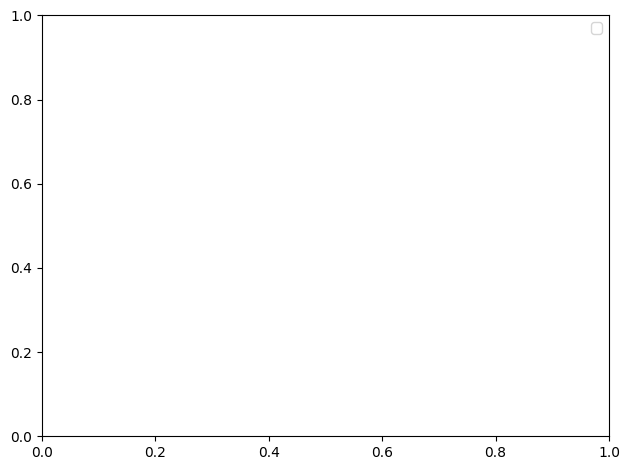

In [10]:
plt.legend()
plt.tight_layout()

plt.savefig("../outputs/model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

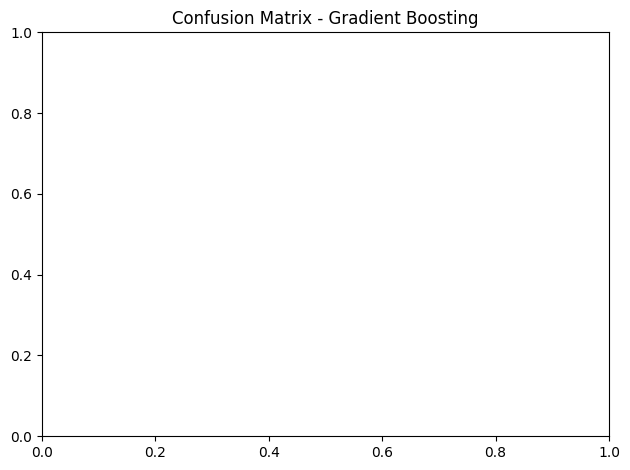

In [11]:
plt.title("Confusion Matrix - Gradient Boosting")
plt.tight_layout()

plt.savefig("../outputs/confusion_matrix_gradient_boosting.png", dpi=300, bbox_inches="tight")

plt.show()

In [12]:
# Save evaluation results

results_display.to_csv(
    "../outputs/model_evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [13]:
# Save simulated evaluation data

evaluation_data = pd.DataFrame({
    "Product_ID": [f"P{i:04d}" for i in range(1, len(y_true) + 1)],
    "Actual_Demand": y_true,
    "Logistic_Regression_Prediction": y_pred_logistic,
    "Random_Forest_Prediction": y_pred_rf,
    "Gradient_Boosting_Prediction": y_pred_gb
})

evaluation_data.to_csv(
    "../data/simulated_apparel_demand_evaluation.csv",
    index=False
)

print("Simulated dataset saved successfully.")

Simulated dataset saved successfully.
